Численно решить уравнение теплопроводности схемой "ромб".

\begin{cases}
\displaystyle \frac{\partial U}{\partial t} = \chi \frac{\partial^2 U}{\partial x^2} + f(x, t), \quad 0 < x < \frac{\pi}{2}, \ 0 < t \leq T, \\[4pt]
U(0, t) = e^{-t}, \\[4pt]
\displaystyle \frac{\partial U}{\partial x}(\frac{\pi}{2}, t) = -e^{-t}, \\[4pt]
U(x, 0) = \cos x,
\end{cases}

где источник
$$
f(x, t) = e^{-t}\cos x \left(\chi - 1\right)
$$

Точное решение задачи:
$$
U_0(x, t) = e^{-t}\cos x.
$$

In [98]:
import numpy as np

In [99]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation

In [100]:
chi = 0.2

L = np.pi / 2
T = 3.0

h = 0.01
tau = 0.0001

In [101]:
TEST_MODE = "INITIAL"

if TEST_MODE == "TAU^2":
    def u_exact(x: np.ndarray, t: float) -> np.ndarray:
        return np.exp(-t) * np.ones_like(x)

    def f(x: np.ndarray, t: float) -> np.ndarray:
        return -np.exp(-t)

    def u_initial(x: np.ndarray) -> float:
        return np.ones_like(x)

    def u_left(t: float) -> float:
        return np.exp(-t)

    def u_right(t: float, U_at_t: np.ndarray) -> float:
        u_x = 0.0
        return (4*U_at_t[-2] - U_at_t[-3] + 2*h*u_x) / 3

else:
    def u_exact(x: np.ndarray, t: float) -> np.ndarray:
        return np.exp(-t) * np.cos(x)

    def f(x: np.ndarray, t: float) -> np.ndarray:
        return np.exp(-t) * np.cos(x) * (chi - 1)

    def u_initial(x: np.ndarray) -> float:
        return np.cos(x)

    def u_left(t: float) -> float:
        return np.exp(-t)

    def u_right(t: float, U_at_t: np.ndarray) -> float:
        u_x = -np.exp(-t)
        return (4*U_at_t[-2] - U_at_t[-3] + 2*h*u_x) / 3

# Numerical solution

In [102]:
def first_step(x: np.ndarray, t: np.ndarray, U: np.ndarray):
    U_predict = np.zeros_like(U[0])
    U_predict[1:-1] = (U[0, 1:-1] +
                      tau * (chi * (U[0, 2:] - 2*U[0, 1:-1] + U[0, :-2]) / h**2 + f(x[1:-1], 0)))

    U_predict[0] = u_left(t[1])
    U_predict[-1] = u_right(t[1], U_predict)

    U[1, 1:-1] = (U[0, 1:-1] +
                    (tau/2) * (
                        chi * (U[0, 2:] - 2*U[0, 1:-1] + U[0, :-2]) / h**2 + f(x[1:-1], 0) +
                        chi * (U_predict[2:] - 2*U_predict[1:-1] + U_predict[:-2]) / h**2 + f(x[1:-1], t[1])
                    ))

    U[1, 0] = u_left(t[1])
    U[1, -1] = u_right(t[1], U[1])


def solve():
    global h, tau

    Nx = int(L / h) + 1
    Nt = int(T / tau) + 1

    x = np.linspace(0, L, Nx)
    h = x[1] - x[0]

    t = np.linspace(0, T, Nt)
    tau = t[1] - t[0]

    U = np.zeros((Nt, Nx))

    U[0, :] = u_initial(x)
    first_step(x, t, U)

    C = 2 * chi * tau / h**2
    for i in range(1, Nt - 1):
        U[i+1, 1:-1] = (
            U[i-1, 1:-1] * (1 - C) +
            C * (U[i, 2:] + U[i, :-2]) +
            2 * tau * f(x[1:-1], t[i])
        ) / (1 + C)

        U[i+1, 0] = u_left(t[i+1])
        U[i+1, -1] = u_right(t[i+1], U[i+1])

    return x, t, U

In [103]:
def convergence_analysis():
    global h, tau

    print("Эксперимент 1: Второй порядок по h (τ ~ h²/5)")
    h_list1 = [0.1, 0.05, 0.025, 0.0125]
    tau_list1 = [0.002, 0.0005, 0.000125, 0.00003125]

    errors_h = []
    for h_val, tau_val in zip(h_list1, tau_list1):
        h = h_val
        tau = tau_val
        print(f"  h={h:.4f}, tau={tau:.6f}, tau/h={tau/h:.4f}")

        x, t, U_num = solve()

        U_true = u_exact(x, T)
        error = np.sqrt(np.sum((U_num[-1, :] - U_true)**2) / np.sum(U_true**2))
        errors_h.append(error)

    print("\nЭксперимент 2: Второй порядок по tau (h фиксированное, малое)")
    h_fixed = 0.05
    tau_list2 = [0.005, 0.0025, 0.00125, 0.000625]

    errors_tau = []
    for tau_val in tau_list2:
        h = h_fixed
        tau = tau_val
        print(f"  h={h:.4f}, tau={tau:.6f}, tau/h={tau/h:.4f}")

        x, t, U_num = solve()

        U_true = u_exact(x, T)
        error = np.sqrt(np.sum((U_num[-1, :] - U_true)**2) / np.sum(U_true**2))
        errors_tau.append(error)

    print("\nЭксперимент 3: Зависимость от τ/h")
    h_base = 0.01
    ratios = [0.8, 0.4, 0.2, 0.1]

    errors_ratio = []
    ratio_values = []
    for ratio in ratios:
        h = h_base
        tau = ratio * h
        print(f"  h={h:.4f}, tau={tau:.6f}, τ/h={ratio:.4f}")

        x, t, U_num = solve()

        U_true = u_exact(x, T)
        error = np.sqrt(np.sum((U_num[-1, :] - U_true)**2) / np.sum(U_true**2))
        errors_ratio.append(error)
        ratio_values.append(ratio)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.loglog(h_list1, errors_h, 'bo-', linewidth=2, markersize=8, label='Численная ошибка')

    h_ref = np.array(h_list1)
    plt.loglog(h_ref, errors_h[0] * (h_ref/h_list1[0])**1, 'r--', alpha=0.5, label='O(h)')
    plt.loglog(h_ref, errors_h[0] * (h_ref/h_list1[0])**2, 'g--', alpha=0.5, label='O(h²)')

    plt.xlabel('h (шаг по пространству)', fontsize=12)
    plt.ylabel('Относительная ошибка', fontsize=12)
    plt.title('Сходимость по h\n(при τ ~ h²)', fontsize=14)
    plt.legend()
    plt.grid(True, which='both', alpha=0.3)

    orders_h = []
    for i in range(1, len(errors_h)):
        order = np.log(errors_h[i-1]/errors_h[i]) / np.log(h_list1[i-1]/h_list1[i])
        orders_h.append(order)
    print(f"\nПорядки по h: {[f'{o:.2f}' for o in orders_h]}")

    plt.subplot(1, 3, 2)
    plt.loglog(tau_list2, errors_tau, 'bo-', linewidth=2, markersize=8, label='Численная ошибка')

    tau_ref = np.array(tau_list2)
    plt.loglog(tau_ref, errors_tau[0] * (tau_ref/tau_list2[0])**1, 'r--', alpha=0.5, label='O(τ)')
    plt.loglog(tau_ref, errors_tau[0] * (tau_ref/tau_list2[0])**2, 'g--', alpha=0.5, label='O(τ²)')

    plt.xlabel('τ (шаг по времени)', fontsize=12)
    plt.ylabel('Относительная ошибка', fontsize=12)
    plt.title('Сходимость по τ\n(при фиксированном малом h)', fontsize=14)
    plt.legend()
    plt.grid(True, which='both', alpha=0.3)

    orders_tau = []
    for i in range(1, len(errors_tau)):
        order = np.log(errors_tau[i-1]/errors_tau[i]) / np.log(tau_list2[i-1]/tau_list2[i])
        orders_tau.append(order)
    print(f"Порядки по τ: {[f'{o:.2f}' for o in orders_tau]}")

    plt.subplot(1, 3, 3)
    plt.loglog(ratio_values, errors_ratio, 'bo-', linewidth=2, markersize=8, label='Численная ошибка')

    r_ref = np.array(ratio_values)
    plt.loglog(r_ref, errors_ratio[0] * (r_ref/ratio_values[0])**1, 'r--', alpha=0.5, label='O((τ/h)¹)')
    plt.loglog(r_ref, errors_ratio[0] * (r_ref/ratio_values[0])**2, 'g--', alpha=0.5, label='O((τ/h)²)')

    plt.xlabel('τ/h', fontsize=12)
    plt.ylabel('Относительная ошибка', fontsize=12)
    plt.title('Зависимость от τ/h\n(при фиксированном h)', fontsize=14)
    plt.legend()
    plt.grid(True, which='both', alpha=0.3)

    orders_ratio = []
    for i in range(1, len(errors_ratio)):
        order = np.log(errors_ratio[i-1]/errors_ratio[i]) / np.log(ratio_values[i-1]/ratio_values[i])
        orders_ratio.append(order)
    print(f"Порядки по τ/h: {[f'{o:.2f}' for o in orders_ratio]}")

    plt.tight_layout()
    plt.show()

    return errors_h, errors_tau, errors_ratio

Эксперимент 1: Второй порядок по h (τ ~ h²/5)
  h=0.1000, tau=0.002000, tau/h=0.0200
  h=0.0500, tau=0.000500, tau/h=0.0100
  h=0.0250, tau=0.000125, tau/h=0.0050
  h=0.0125, tau=0.000031, tau/h=0.0025

Эксперимент 2: Второй порядок по tau (h фиксированное, малое)
  h=0.0500, tau=0.005000, tau/h=0.1000
  h=0.0500, tau=0.002500, tau/h=0.0500
  h=0.0500, tau=0.001250, tau/h=0.0250
  h=0.0500, tau=0.000625, tau/h=0.0125

Эксперимент 3: Зависимость от τ/h
  h=0.0100, tau=0.008000, τ/h=0.8000
  h=0.0100, tau=0.004000, τ/h=0.4000
  h=0.0100, tau=0.002000, τ/h=0.2000
  h=0.0100, tau=0.001000, τ/h=0.1000

Порядки по h: ['2.10', '2.00', '2.03']
Порядки по τ: ['3.68', '-1.13', '-0.42']
Порядки по τ/h: ['2.03', '2.01', '2.01']


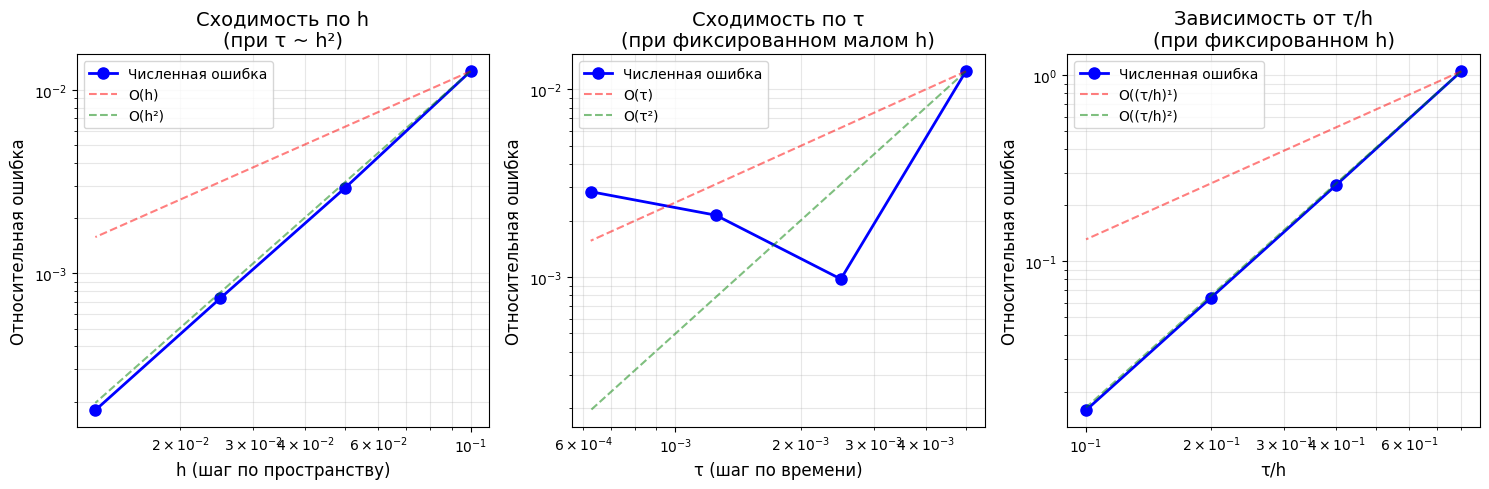

In [104]:
errors_h, errors_tau, errors_ratio = convergence_analysis()

In [105]:
def animate_solution(filename: str = None, frame_skip: int = 10, speed_factor: float = 2.0):
    from matplotlib.gridspec import GridSpec

    print("Решение задачи...")
    x, t, U_num = solve()

    print("Вычисление точного решения...")
    U_true = np.zeros_like(U_num)
    for j in range(len(t)):
        U_true[j, :] = u_exact(x, t[j])

    global_min = min(U_num.min(), U_true.min())
    global_max = max(U_num.max(), U_true.max())
    y_padding = (global_max - global_min) * 0.1

    all_errors = np.abs(U_num - U_true)
    global_err_max = all_errors.max() * 1.2
    max_errors_per_frame = all_errors.max(axis=1)

    fig = plt.figure(figsize=(16, 8))
    gs = GridSpec(2, 3, figure=fig, width_ratios=[2, 2, 1], height_ratios=[1, 1])

    ax1 = fig.add_subplot(gs[:, :2])
    line_num, = ax1.plot(x, U_num[0, :], 'b-', lw=2, label='Численное')
    line_exact, = ax1.plot(x, U_true[0, :], 'r--', lw=2, label='Точное', alpha=0.8)
    ax1.set_xlabel('x', fontsize=14)
    ax1.set_ylabel('U(x,t)', fontsize=14)
    ax1.set_title('Схема Дюфорта-Франкеля (шаблон "ромб")', fontsize=16, fontweight='bold')
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.legend(loc='upper right', fontsize=12)
    ax1.set_xlim(0, L)
    ax1.set_ylim(global_min - y_padding, global_max + y_padding)

    ax2 = fig.add_subplot(gs[0, 2])
    line_err, = ax2.plot(x, all_errors[0, :], 'g-', lw=2)
    ax2.set_xlabel('x', fontsize=12)
    ax2.set_ylabel('Ошибка', fontsize=12)
    ax2.set_title('Абсолютная ошибка', fontsize=14)
    ax2.grid(True, alpha=0.3, linestyle='--')
    ax2.set_xlim(0, L)
    ax2.set_ylim(0, global_err_max)

    ax3 = fig.add_subplot(gs[1, 2])
    line_history, = ax3.plot([], [], 'mo-', markersize=3, linewidth=1.5)
    ax3.set_xlabel('Время t', fontsize=12)
    ax3.set_ylabel('Макс. ошибка', fontsize=12)
    ax3.set_title('Эволюция ошибки', fontsize=14)
    ax3.grid(True, alpha=0.3, linestyle='--')
    ax3.set_xlim(0, T)
    ax3.set_ylim(0, max_errors_per_frame.max() * 1.1)

    time_text = ax1.text(0.02, 0.98, f't = {t[0]:.3f} с', transform=ax1.transAxes,
                         fontsize=14, fontweight='bold',
                         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    error_text = ax2.text(0.05, 0.95, f'Макс: {max_errors_per_frame[0]:.2e}',
                          transform=ax2.transAxes,
                          fontsize=12, fontweight='bold',
                          bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

    param_text = ax1.text(0.98, 0.02, f'$\\chi={chi}$, $h={h:.4f}$, $\\tau={tau:.4f}$',
                         transform=ax1.transAxes, fontsize=10,
                         ha='right', va='bottom',
                         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

    time_marker = ax3.axvline(x=0, color='red', linestyle='--', alpha=0.5, linewidth=1)

    plt.tight_layout()

    n_frames = len(t)
    frame_step = max(1, frame_skip)
    frames_indices = list(range(0, n_frames, frame_step))

    base_interval = 50

    interval_ms = base_interval * speed_factor

    dt_real = t[1] - t[0]
    dt_frame = dt_real * frame_step

    print(f"Физическое время между кадрами: {dt_frame:.4f} с")
    print(f"Интервал между кадрами: {interval_ms:.1f} мс")
    print(f"Всего кадров: {len(frames_indices)}")
    print(f"Длительность анимации: {len(frames_indices) * interval_ms / 1000:.2f} с (реального времени анимации)")
    print(f"Физическое время задачи: {T} с")
    print(f"Соотношение (анимация/физика): {len(frames_indices) * interval_ms / 1000 / T:.2f}")

    def update(frame_idx):
        actual_idx = frames_indices[frame_idx]

        line_num.set_ydata(U_num[actual_idx, :])
        line_exact.set_ydata(U_true[actual_idx, :])
        line_err.set_ydata(all_errors[actual_idx, :])

        mask = np.arange(len(t)) <= actual_idx
        line_history.set_data(t[mask], max_errors_per_frame[mask])

        time_text.set_text(f't = {t[actual_idx]:.3f} с')
        error_text.set_text(f'Макс: {max_errors_per_frame[actual_idx]:.2e}')

        time_marker.set_xdata([t[actual_idx], t[actual_idx]])

        return line_num, line_exact, line_err, line_history, time_marker, time_text, error_text

    anim = animation.FuncAnimation(fig, update, frames=range(len(frames_indices)),
                                   interval=interval_ms, blit=True, repeat=True)

    if filename:
        print(f"Сохранение анимации в {filename}...")
        fps = 1000 / interval_ms
        anim.save(filename, writer='ffmpeg', fps=fps, dpi=150)
        print("Анимация сохранена!")

    plt.show()
    return anim

Решение задачи...
Вычисление точного решения...
Физическое время между кадрами: 0.0100 с
Интервал между кадрами: 150.0 мс
Всего кадров: 301
Длительность анимации: 45.15 с (реального времени анимации)
Физическое время задачи: 3.0 с
Соотношение (анимация/физика): 15.05
Сохранение анимации в solution.mp4...
Анимация сохранена!


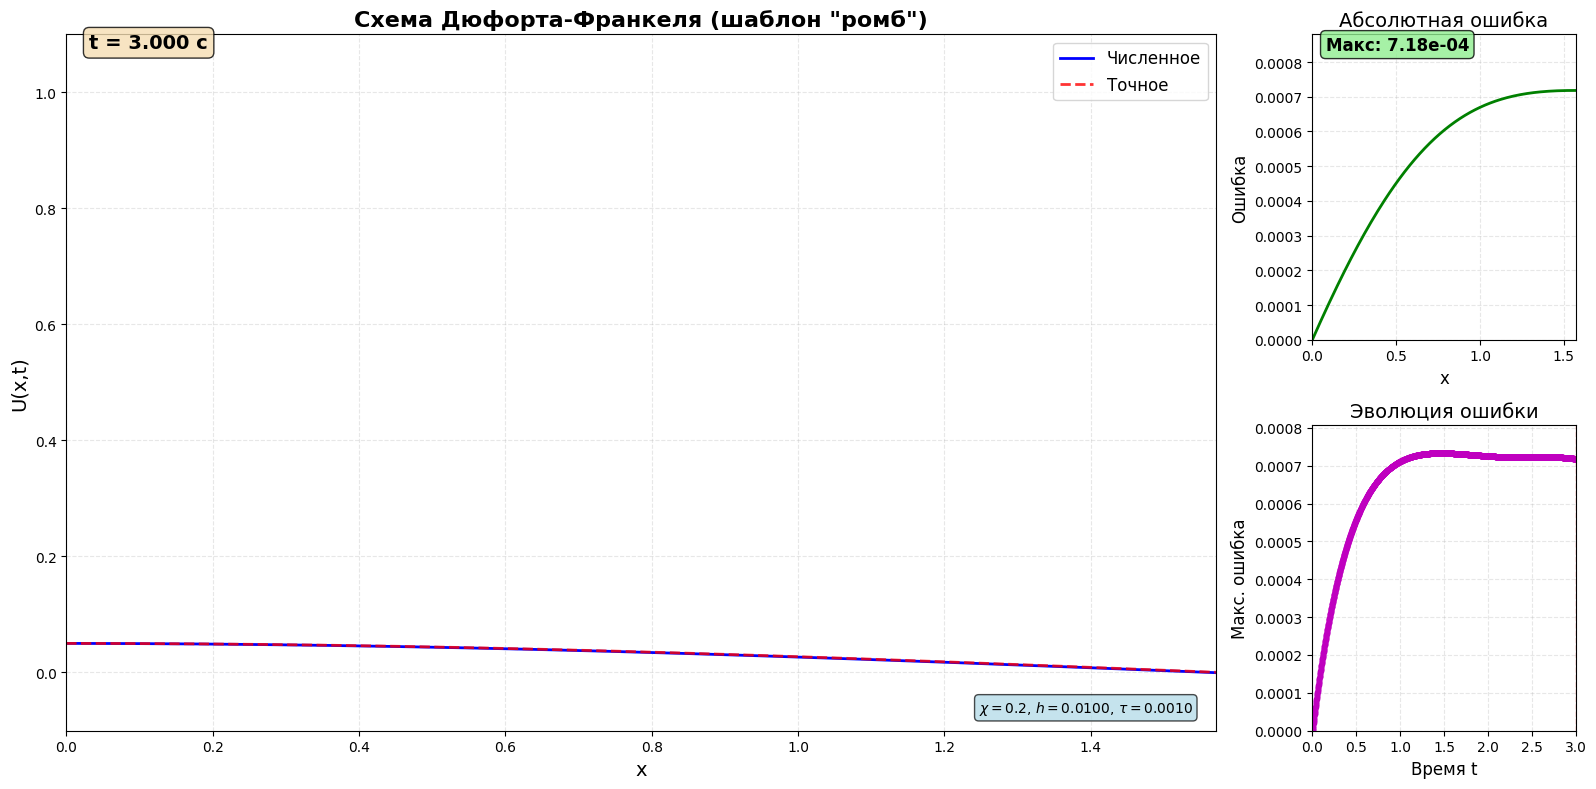

In [106]:
anim = animate_solution(filename="solution.mp4", frame_skip=10, speed_factor=3.0)